In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from sklearn.linear_model import LinearRegression

In [3]:
fnames = utils.get_filenames()

In [4]:
fname = fnames["london"][-1]

In [5]:
data = nwbWrapper(fname, region="OFC")

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 625.85it/s]


loading choice data:


100%|██████████| 2545/2545 [00:01<00:00, 1435.51it/s]


In [52]:
trial = 3
X, Y = np.where(data.trial_spikes[trial].neural)
eyes = data.trial_spikes[trial].eyes

trialX = data.choice_df.query("trial == @trial")
trialX.head()

plan_trial = data.fixation_df.query("active_prob <= 0.2 & trial == @trial")
plan_trial.head()

trial_ts = utils.trial_ts(data.trial_spikes[trial])

In [55]:
trial_ts

{'t': array([0.00000000e+00, 1.00020738e+00, 2.00041477e+00, ...,
        4.82099959e+03, 4.82199979e+03, 4.82300000e+03]),
 'start': np.float64(887.5569000374526),
 'first_choice': np.float64(2038.9405999332666),
 'reward': np.float64(4186.61139998585),
 'ml_start_time': np.float64(48412.0)}

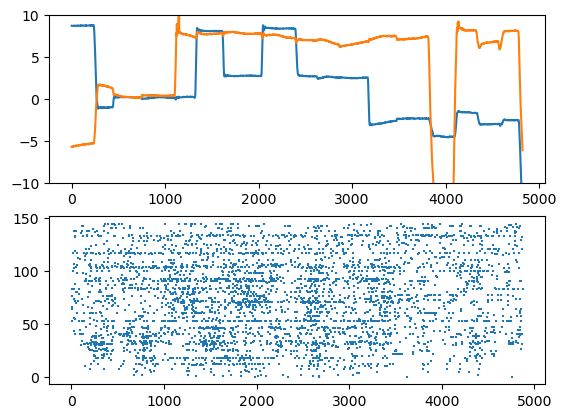

In [53]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(eyes[:, 0])
ax[0].plot(eyes[:, 1])
ax[0].set_ylim([-10, 10])
ax[1].scatter(X, Y, s = 1, marker = "|")

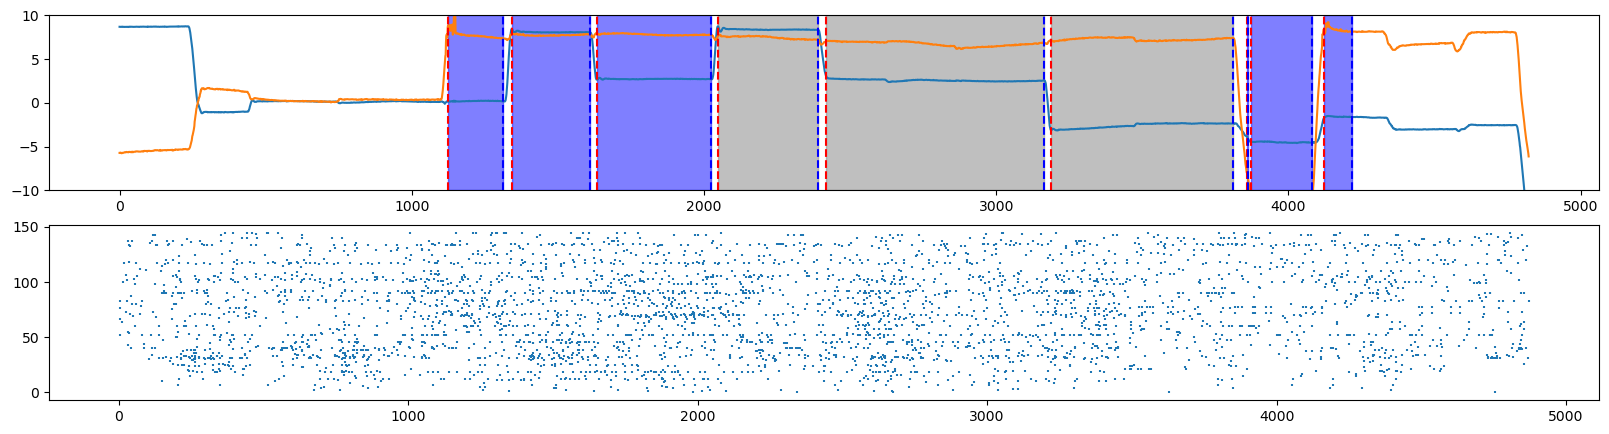

In [56]:
fig, ax = plt.subplots(2, 1, figsize=(20, 5))
ax[0].plot(eyes[:, 0])
ax[0].plot(eyes[:, 1])
ax[0].set_ylim([-10, 10])
ax[1].scatter(X, Y, s = 1, marker = "|")

for i, choice in trialX.iterrows():
    start_time = choice["fix_on"] - trial_ts["ml_start_time"]
    end_time = choice["fix_off"] - trial_ts["ml_start_time"]

    ax[0].axvline(start_time, color = "red", linestyle = "--")
    ax[0].axvline(end_time, color = "blue", linestyle = "--")
    ax[0].fill_betweenx([-10, 10], start_time, end_time, color = "gray", alpha = 0.5)
    
for i, plan in plan_trial.iterrows():
    start_time = plan["start_time"] - trial_ts["ml_start_time"]
    end_time = plan["stop_time"] - trial_ts["ml_start_time"]

    ax[0].axvline(start_time, color = "red", linestyle = "--")
    ax[0].axvline(end_time, color = "blue", linestyle = "--")
    ax[0].fill_betweenx([-10, 10], start_time, end_time, color = "blue", alpha = 0.5)

In [39]:
idx = data.choice_df.trial == 2
data.choice_spikes[idx, :, :].shape

(3, 1000, 145)

In [58]:
data.get_plan_spikes(type="mean")

100%|██████████| 943/943 [00:00<00:00, 2555.80it/s]


{'spikes': array([[0.        , 0.00613497, 0.        , ..., 0.00613497, 0.        ,
         0.        ],
        [0.00574713, 0.        , 0.00574713, ..., 0.00574713, 0.        ,
         0.        ],
        [0.        , 0.        , 0.00510204, ..., 0.00510204, 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.05      , 0.        ,
         0.        ],
        [0.        , 0.        , 0.00574713, ..., 0.02298851, 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.02116402, 0.00529101,
         0.00529101]]),
 'df':       start_time  stop_time  trial_start_time  trial_stop_time  trial  \
 id                                                                      
 5        43326.0    43489.0           42224.0     4.696151e+04      2   
 7        44062.0    44236.0           42224.0     4.696151e+04      2   
 9        44583.0    44975.0           42224.0     4.696151e+04      2   
 10       44997.0    45

In [41]:
data.fixation_df.query("active_prob <= 0.2")

,start_time,stop_time,trial_start_time,trial_stop_time,trial,trialerror,nsteps,start,target,block,...,active_prob,step_on,step_off,node_on,node_off,fix_node,entropy_ratio,t_middle,window_size,graph_distance
id,,,,,,,,,,,,,,,,,,,,,
1,36434.0,36435.0,34858.0,3.717851e+04,0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,13,0.299892,36434.5,500,3
2,36464.0,36519.0,34858.0,3.717851e+04,0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,14,0.091939,36491.5,500,3
4,39978.0,40118.0,38629.0,4.077246e+04,1,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,15,0.127171,40048.0,500,2
5,43326.0,43489.0,42224.0,4.696151e+04,2,0.0,2.0,15.0,1.0,1.0,...,0.0,0.0,0.0,15.0,15.0,1,0.107432,43407.5,500,0
7,44062.0,44236.0,42224.0,4.696151e+04,2,0.0,2.0,15.0,1.0,1.0,...,0.0,1.0,1.0,15.0,15.0,11,0.138473,44149.0,500,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6092,5896240.0,5896437.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,15,0.157789,5896338.5,500,2
6093,5896459.0,5896599.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,11,0.174265,5896529.0,500,1
6094,5896633.0,5896807.0,5888511.0,5.900439e+06,952,0.0,7.0,4.0,7.0,95.0,...,0.0,5.0,5.0,1.0,1.0,3,0.336590,5896720.0,500,1
